# <span style="color:blue">Obesity Dataset</span>
This is a dataset from kaggle (https://www.kaggle.com/competitions/playground-series-s4e2/overview)
In this project we're going to try out different classification models, independent and dependent ensemble models and pick the one with the best accuracy. For the accuracy metric we're gonna use F1 Score as the data is imbalanced.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, VotingClassifier, StackingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [2]:
train = pd.read_csv(r"C:\Users\User\Downloads\train.csv")
test = pd.read_csv(r"C:\Users\User\Downloads\test.csv")
res = pd.read_csv(r"C:\Users\User\Downloads\sample_submission.csv")

In [3]:
train

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20753,20753,Male,25.137087,1.766626,114.187096,yes,yes,2.919584,3.000000,Sometimes,no,2.151809,no,1.330519,0.196680,Sometimes,Public_Transportation,Obesity_Type_II
20754,20754,Male,18.000000,1.710000,50.000000,no,yes,3.000000,4.000000,Frequently,no,1.000000,no,2.000000,1.000000,Sometimes,Public_Transportation,Insufficient_Weight
20755,20755,Male,20.101026,1.819557,105.580491,yes,yes,2.407817,3.000000,Sometimes,no,2.000000,no,1.158040,1.198439,no,Public_Transportation,Obesity_Type_II
20756,20756,Male,33.852953,1.700000,83.520113,yes,yes,2.671238,1.971472,Sometimes,no,2.144838,no,0.000000,0.973834,no,Automobile,Overweight_Level_II


In [4]:
train.isna().sum()

id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [5]:
train.NObeyesdad.value_counts(dropna = False)

NObeyesdad
Obesity_Type_III       4046
Obesity_Type_II        3248
Normal_Weight          3082
Obesity_Type_I         2910
Insufficient_Weight    2523
Overweight_Level_II    2522
Overweight_Level_I     2427
Name: count, dtype: int64

In [6]:
train.family_history_with_overweight.value_counts()

family_history_with_overweight
yes    17014
no      3744
Name: count, dtype: int64

In [7]:
train.drop('id', axis=1, inplace = True)
train.Gender = (train.Gender == 'Female').astype('int8')
train.family_history_with_overweight = (train.family_history_with_overweight == 'yes').astype('int8')
train.FAVC = (train.FAVC == 'yes').astype('int8')

In [8]:
train.CAEC.value_counts()

CAEC
Sometimes     17529
Frequently     2472
Always          478
no              279
Name: count, dtype: int64

In [9]:
data_info = {}

In [10]:
data_info['CAEC_'] = train.CAEC.value_counts(normalize = True)
for i in data_info['CAEC_'].keys():
    train[f'CAEC_{i}'] = (train.CAEC==i).astype('int8')
train.drop('CAEC',axis=1,inplace=True)

In [11]:
train

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,CAEC_Sometimes,CAEC_Frequently,CAEC_Always,CAEC_no
0,0,24.443011,1.699998,81.669950,1,1,2.000000,2.983297,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II,1,0,0,0
1,1,18.000000,1.560000,57.000000,1,1,2.000000,3.000000,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight,0,1,0,0
2,1,18.000000,1.711460,50.165754,1,1,1.880534,1.411685,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight,1,0,0,0
3,1,20.952737,1.710730,131.274851,1,1,3.000000,3.000000,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III,1,0,0,0
4,0,31.641081,1.914186,93.798055,1,1,2.679664,1.971472,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20753,0,25.137087,1.766626,114.187096,1,1,2.919584,3.000000,no,2.151809,no,1.330519,0.196680,Sometimes,Public_Transportation,Obesity_Type_II,1,0,0,0
20754,0,18.000000,1.710000,50.000000,0,1,3.000000,4.000000,no,1.000000,no,2.000000,1.000000,Sometimes,Public_Transportation,Insufficient_Weight,0,1,0,0
20755,0,20.101026,1.819557,105.580491,1,1,2.407817,3.000000,no,2.000000,no,1.158040,1.198439,no,Public_Transportation,Obesity_Type_II,1,0,0,0
20756,0,33.852953,1.700000,83.520113,1,1,2.671238,1.971472,no,2.144838,no,0.000000,0.973834,no,Automobile,Overweight_Level_II,1,0,0,0


In [12]:
train.SMOKE = (train.SMOKE == 'yes').astype('int8')

In [13]:
train.SCC = (train.SCC == 'yes').astype('int8')

In [14]:
data_info['CALC_'] = train.CALC.value_counts(normalize = True)
for i in data_info['CALC_'].keys():
    train[f'CALC_{i}'] = (train.CALC==i).astype('int8')
train.drop('CALC',axis=1,inplace=True)

In [15]:
train.MTRANS.value_counts(dropna = False)

MTRANS
Public_Transportation    16687
Automobile                3534
Walking                    467
Motorbike                   38
Bike                        32
Name: count, dtype: int64

In [16]:
data_info['MTRANS_'] = train.MTRANS.value_counts(normalize = True)
for i in data_info['MTRANS_'].keys():
    train[f'MTRANS_{i}'] = (train.MTRANS==i).astype('int8')
train.drop('MTRANS',axis=1,inplace=True)

In [17]:
train.NObeyesdad

0        Overweight_Level_II
1              Normal_Weight
2        Insufficient_Weight
3           Obesity_Type_III
4        Overweight_Level_II
                ...         
20753        Obesity_Type_II
20754    Insufficient_Weight
20755        Obesity_Type_II
20756    Overweight_Level_II
20757        Obesity_Type_II
Name: NObeyesdad, Length: 20758, dtype: str

In [18]:
lb = LabelEncoder()
train.NObeyesdad = lb.fit_transform(train.NObeyesdad)

In [19]:
train.NObeyesdad.value_counts()

NObeyesdad
4    4046
3    3248
1    3082
2    2910
0    2523
6    2522
5    2427
Name: count, dtype: int64

In [20]:
x = train.drop('NObeyesdad',axis = 1)
y = train.NObeyesdad.values

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

In [22]:
x_train.shape, x_test.shape 

((16606, 25), (4152, 25))

In [23]:
train.family_history_with_overweight.value_counts()

family_history_with_overweight
1    17014
0     3744
Name: count, dtype: int64

<Axes: >

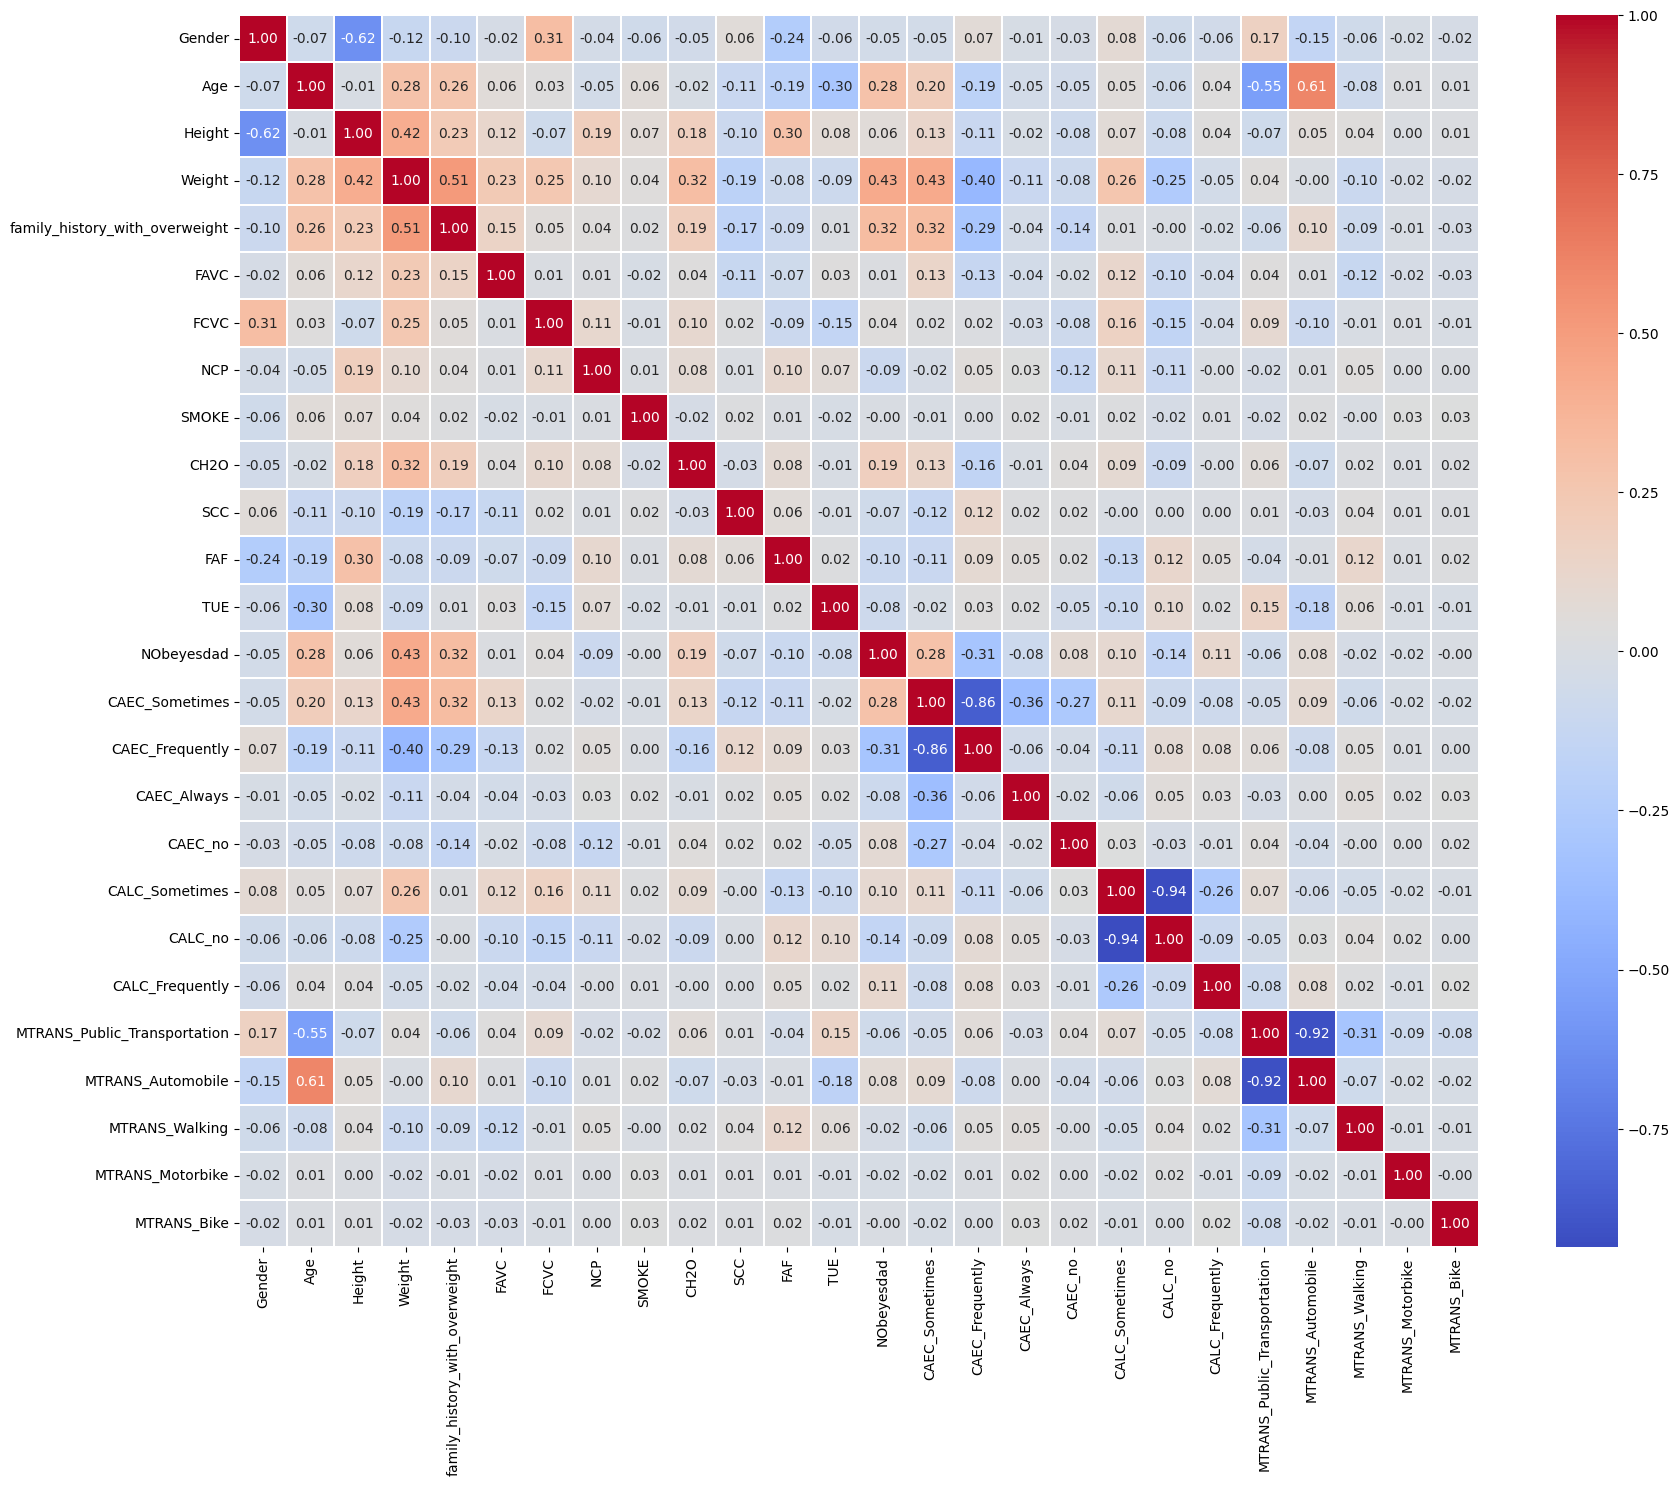

In [24]:
plt.figure(figsize=(20, 16))
sns.heatmap(train.corr(), annot = True, fmt = '.2f', cmap = 'coolwarm', linewidths = 0.1)

We're going to evaluate Logistic Regression, KNN, Decision Tree models for this dataset, and also we're going to try ensemble methods - 
Bagging, Voting, Stacking (independent models), RandomForest and boosting algorithms (AdaBoost, XGboost, Catboost, Lightgbm)

In [25]:
sc = MinMaxScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [26]:
lg = LogisticRegression()
lg.fit(x_train, y_train)

C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [27]:
tr = f1_score(y_train, lg.predict(x_train), average='macro')
te = f1_score(y_test, lg.predict(x_test), average='macro')
print(f'Train: {tr}\nTest: {te}')

Train: 0.7955047769983645
Test: 0.7836779556035882


In [28]:
params = {'n_neighbors': list(range(1,30))}
knn = KNeighborsClassifier()
gd = GridSearchCV(estimator = knn, param_grid = params, cv=5, n_jobs = -1)
gd.fit(x_train,y_train)
best_knn = gd.best_estimator_
best_score = gd.best_score_
best_params = gd.best_params_
print(f"best score: {best_score}\n best params: {best_params}")
print(f'train: {f1_score(y_train, best_knn.predict(x_train),average='macro')}') 
print(f'test: {f1_score(y_test, best_knn.predict(x_test),average='macro')}')  

best score: 0.7151027314005831
 best params: {'n_neighbors': 5}
train: 0.782189785968791
test: 0.6889071654212529


In [29]:
params_grid = {
        'max_depth': [3, 5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10, 12, 13],
        'min_samples_leaf': [1, 2, 4, 5, 6],
        'criterion': ['gini', 'entropy']
    }
dt = DecisionTreeClassifier(random_state=0)
gdt = GridSearchCV(estimator = dt , param_grid = params_grid, cv=5, n_jobs = -1)
gdt.fit(x_train,y_train)
best_dt = gdt.best_estimator_
best_score = gdt.best_score_
best_params = gdt.best_params_
print(f"best score: {best_score}\n best params: {best_params}")
print(f'train: {f1_score(y_train, best_dt.predict(x_train),average='macro')}') 
print(f'test: {f1_score(y_test, best_dt.predict(x_test),average='macro')}')  

best score: 0.8752863258112814
 best params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 13}
train: 0.898733927703631
test: 0.8628322319013695


In [30]:
params_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],        
    'learning_rate': [0.1, 0.3],
}
xgb = XGBClassifier(random_state=0)
g = GridSearchCV(estimator = xgb , param_grid = params_xgb, cv=5, n_jobs = -1)
g.fit(x_train,y_train)
best_xgb = g.best_estimator_
best_score = g.best_score_
best_params = g.best_params_
print(f"best score: {best_score}\n best params: {best_params}")
print(f'train: {f1_score(y_train, best_xgb.predict(x_train),average='macro')}') 
print(f'test: {f1_score(y_test, best_xgb.predict(x_test),average='macro')}')  


best score: 0.907985125941299
 best params: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 200}
train: 0.9420875166737365
test: 0.8912874890479839


In [31]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=0,
    n_jobs=-1

)
bag.fit(x_train,y_train)
print(f"Train: {f1_score(y_train, bag.predict(x_train), average = 'macro'):.4f}")
print(f"Test:  {f1_score(y_test,  bag.predict(x_test), average = 'macro'):.4f}")

Train: 0.9996
Test:  0.8842


In [32]:
vot = VotingClassifier(
    estimators=[
    ('lr',  LogisticRegression()),
    ('dt',  best_dt),       
    ('xgb', best_xgb)
    ],
    voting='soft',
    n_jobs=-1

)
vot.fit(x_train,y_train)
print(f"Train: {f1_score(y_train, vot.predict(x_train), average = 'macro'):.4f}")
print(f"Test:  {f1_score(y_test,  vot.predict(x_test), average = 'macro'):.4f}")

Train: 0.9265
Test:  0.8892


In [33]:
stack = StackingClassifier(
    estimators=[
    ('bag',  bag),
    ('dt',  best_dt),       
    ('xgb', best_xgb)],
    final_estimator=LogisticRegression(),
    
    cv = 5,
    n_jobs=-1

)
stack.fit(x_train,y_train)
print(f"Train: {f1_score(y_train, stack.predict(x_train), average = 'macro'):.4f}")
print(f"Test:  {f1_score(y_test,  stack.predict(x_test), average = 'macro'):.4f}")

Train: 0.9530
Test:  0.8950


In [34]:
lgbm = LGBMClassifier(n_estimators=50,
                    learning_rate=0.1,
                     max_depth=7,
                 random_state=0,
                    n_jobs=-1)
cat = CatBoostClassifier(n_estimators=50,
                    learning_rate=0.1,
                     max_depth=7,
                 random_state=0,
                    )
lgbm.fit(x_train,y_train)
cat.fit(x_train,y_train)
print("── LightGBM ──")
print(f"Train: {f1_score(y_train, lgbm.predict(x_train), average='macro'):.4f}")
print(f"Test:  {f1_score(y_test,  lgbm.predict(x_test),  average='macro'):.4f}")
print("── CatBoost ──")
print(f"Train: {f1_score(y_train, cat.predict(x_train), average='macro'):.4f}")
print(f"Test:  {f1_score(y_test,  cat.predict(x_test),  average='macro'):.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005932 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2062
[LightGBM] [Info] Number of data points in the train set: 16606, number of used features: 25
[LightGBM] [Info] Start training from score -2.094366
[LightGBM] [Info] Start training from score -1.912860
[LightGBM] [Info] Start training from score -1.964755
[LightGBM] [Info] Start training from score -1.863915
[LightGBM] [Info] Start training from score -1.634499
[LightGBM] [Info] Start training from score -2.139374
[LightGBM] [Info] Start training from score -2.110635
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
0:	learn: 1.6102336	total: 306ms	remaining: 15s
1:	learn: 1.4147986	total: 409ms	remaining: 9.81s
2:	learn: 1.2686056	total: 510ms	remaining: 7.98s
3:	learn: 1.1542685	total: 614ms	remaining: 7.

C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Train: 0.9383
Test:  0.8966
── CatBoost ──
Train: 0.8837
Test:  0.8730


C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [35]:
ada = AdaBoostClassifier(estimator = DecisionTreeClassifier(criterion =  'entropy', max_depth = 10, min_samples_leaf = 5, min_samples_split = 13 ),
                    learning_rate=0.3,
                 random_state=0,
                    )
ada.fit(x_train,y_train)
print("── AdaBoost ──")
print(f"Train: {f1_score(y_train, ada.predict(x_train), average='macro'):.4f}")
print(f"Test:  {f1_score(y_test,  ada.predict(x_test),  average='macro'):.4f}")

── AdaBoost ──
Train: 0.9973
Test:  0.8790


In [36]:
rf = RandomForestClassifier(n_estimators = 10)
rf.fit(x_train,y_train)
print("── Random Forest ──")
print(f"Train: {f1_score(y_train, rf.predict(x_train), average='macro'):.4f}")
print(f"Test:  {f1_score(y_test,  rf.predict(x_test),  average='macro'):.4f}")

── Random Forest ──
Train: 0.9935
Test:  0.8550


In [37]:
results = {
    'Logistic Regression': f1_score(y_test, lg.predict(x_test), average='macro'),
    'KNN':                 f1_score(y_test, best_knn.predict(x_test), average='macro'),
    'Decision Tree':       f1_score(y_test, best_dt.predict(x_test), average='macro'),
    'XGBoost':             f1_score(y_test, best_xgb.predict(x_test), average='macro'),
    'Bagging':             f1_score(y_test, bag.predict(x_test), average='macro'),
    'Voting':              f1_score(y_test, vot.predict(x_test), average='macro'),
    'Stacking':            f1_score(y_test, stack.predict(x_test), average='macro'),
    'LightGBM':            f1_score(y_test, lgbm.predict(x_test), average='macro'),
    'CatBoost':            f1_score(y_test, cat.predict(x_test), average='macro'),
    'AdaBoost':            f1_score(y_test, ada.predict(x_test), average='macro'),
    'Random Forest':       f1_score(y_test, rf.predict(x_test), average='macro'),
}
pd.Series(results).sort_values(ascending=False)

C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM               0.896625
Stacking               0.894970
XGBoost                0.891287
Voting                 0.889221
Bagging                0.884178
AdaBoost               0.878995
CatBoost               0.873019
Decision Tree          0.862832
Random Forest          0.855046
Logistic Regression    0.783678
KNN                    0.688907
dtype: float64

In [38]:
test.drop('id', axis=1, inplace = True)
test.Gender = (test.Gender == 'Female').astype('int8')
test.family_history_with_overweight = (test.family_history_with_overweight == 'yes').astype('int8')
test.FAVC = (test.FAVC == 'yes').astype('int8')

for i in data_info['CAEC_'].keys():
    test[f'CAEC_{i}'] = (test.CAEC==i).astype('int8')
test.drop('CAEC',axis=1,inplace=True)

test.SMOKE = (test.SMOKE == 'yes').astype('int8')
test.SCC = (test.SCC == 'yes').astype('int8')

for i in data_info['CALC_'].keys():
    test[f'CALC_{i}'] = (test.CALC==i).astype('int8')
test.drop('CALC',axis=1,inplace=True)

for i in data_info['MTRANS_'].keys():
    test[f'MTRANS_{i}'] = (test.MTRANS==i).astype('int8')
test.drop('MTRANS',axis=1,inplace=True)

In [39]:
s = MinMaxScaler()

train = s.fit_transform(x)
test = s.transform(test)

In [40]:
lgb = LGBMClassifier(n_estimators=50,
                    learning_rate=0.1,
                     max_depth=7,
                 random_state=0,
                    n_jobs=-1)
lgb.fit(train, y)
ans = lgb.predict(test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006937 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2058
[LightGBM] [Info] Number of data points in the train set: 20758, number of used features: 25
[LightGBM] [Info] Start training from score -2.107483
[LightGBM] [Info] Start training from score -1.907353
[LightGBM] [Info] Start training from score -1.964779
[LightGBM] [Info] Start training from score -1.854892
[LightGBM] [Info] Start training from score -1.635203
[LightGBM] [Info] Start training from score -2.146276
[LightGBM] [Info] Start training from score -2.107879
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [41]:
ans = lb.inverse_transform(ans)

In [42]:
res['NObeyesdad'] = ans

In [43]:
res

,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Overweight_Level_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_I
4,20762,Obesity_Type_III
...,...,...
13835,34593,Overweight_Level_II
13836,34594,Overweight_Level_I
13837,34595,Insufficient_Weight
13838,34596,Normal_Weight


In [44]:
res.to_csv('ObesitySubmission.csv', index = False)